1.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2.

In [2]:
edu_df = pd.read_csv('edu_users.csv')

3.

In [3]:
edu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_math        1188 non-null   float64
 1   rate_science     1188 non-null   float64
 2   rate_english     1250 non-null   float64
 3   rate_humanities  1250 non-null   float64
 4   rate_art         1250 non-null   float64
 5   tot_time         1188 non-null   float64
 6   device           1250 non-null   object 
 7   gender           1250 non-null   object 
 8   age              1250 non-null   int64  
 9   resub_yn         1250 non-null   object 
 10  comb_yn          1250 non-null   object 
 11  othersub_yn      1250 non-null   object 
 12  leave_yn         1250 non-null   int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 127.1+ KB


In [ ]:
답03 = '4'

4.

In [4]:
corr_list = ['rate_math', 'rate_science', 'rate_english', 'rate_humanities', 'rate_art']

<Axes: >

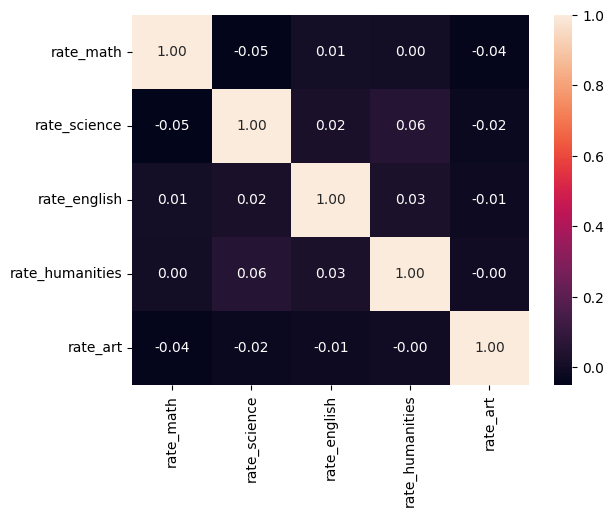

In [7]:
sns.heatmap(data=edu_df[corr_list].corr(), annot=True, fmt='.2f')

In [ ]:
답04 = '3'

5.

<Axes: xlabel='leave_yn', ylabel='tot_time'>

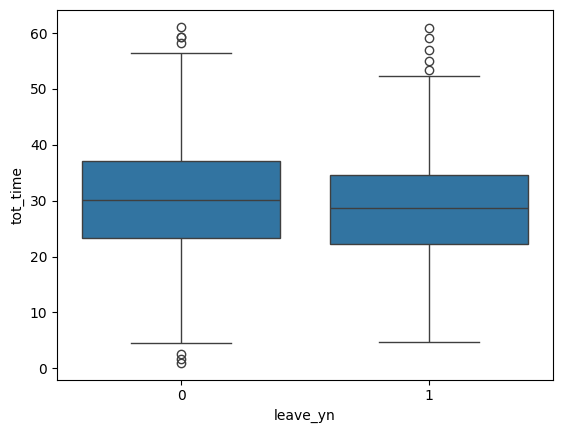

In [8]:
sns.boxplot(data=edu_df, x='leave_yn', y='tot_time')

In [ ]:
답05 = '3'

6.

In [9]:
edu_df.pivot_table(index='leave_yn', values=['rate_math', 'rate_science'], aggfunc='mean')

,rate_math,rate_science
leave_yn,,
0,0.487965,0.496375
1,0.515511,0.505424


7.

In [10]:
edu_df['rate_math'] = edu_df['rate_math'].fillna(edu_df['rate_math'].mean())
edu_df['rate_science'] = edu_df['rate_science'].fillna(edu_df['rate_science'].median())
edu_df['tot_time'] = edu_df['tot_time'].fillna(edu_df['tot_time'].mode()[0])

8.

In [12]:
from sklearn.model_selection import train_test_split

X = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']]
y = edu_df['leave_yn']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

9.

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [14]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

10.

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
rfc = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_split=5, random_state=42)

rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, min_samples_split=5, n_estimators=150,
                       random_state=42)

11.

In [17]:
from xgboost import XGBClassifier

In [18]:
xgbc = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)

xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

12.

In [23]:
from sklearn.metrics import accuracy_score, f1_score

rfc_predict = rfc.predict(X_test)
xgbc_predict = xgbc.predict(X_test)

print('RFC')
print('ACC :', accuracy_score(y_valid, rfc_predict))
print('F1 :', f1_score(y_valid, rfc_predict))

print('XGBC')
print('ACC :', accuracy_score(y_valid, xgbc_predict))
print('F1 :', f1_score(y_valid, xgbc_predict))

RFC
ACC : 0.632
F1 : 0.02127659574468085
XGBC
ACC : 0.604
F1 : 0.24427480916030533


In [ ]:
답12 = 'RF'

13.

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(10)

In [25]:
from sklearn import metrics
model = Sequential()

model.add(Dense(64, activation='selu', input_shape = (X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=45, batch_size=32)

Epoch 1/45


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6050 - loss: 0.6873
Epoch 2/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6900 - loss: 0.6318
Epoch 3/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6920 - loss: 0.6213
Epoch 4/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6930 - loss: 0.6139
Epoch 5/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6960 - loss: 0.6096
Epoch 6/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6960 - loss: 0.6067
Epoch 7/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6980 - loss: 0.6041
Epoch 8/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - loss: 0.6019
Epoch 9/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6980 - loss: 0.6002
Epoch 10/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6980 - loss: 0.5987
Epoch 11/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.5972
Epoch 12/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7000 - loss: 0.5959


14.

In [26]:
simul_data = np.array([[0.3, 0.5, 0.7, 120]])

In [27]:
deep_pre = model.predict(simul_data)

답14 = np.where(deep_pre < 0.5, 0, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
